<div align="center">

#### Lab 3

# National Tsing Hua University

#### Spring 2025

#### 11320IEEM 513600

#### Deep Learning and Industrial Applications
    
## Lab 3: Anomaly Detection in Industrial Applications

</div>


### Introduction

In today's industrial landscape, the ability to detect anomalies in manufacturing processes and products is critical for maintaining quality, efficiency, and safety. This lab focuses on leveraging deep learning techniques for anomaly detection in various industrial applications, using the MVTEC Anomaly Detection Dataset. By employing ImageNet-pretrained models available in torchvision, students will gain hands-on experience in classfying defects and irregularities across different types of industrial products.

Throughout this lab, you'll be involved in the following key activities:
- Explore and process the MVTec Anomaly Detection Dataset.
- Apply ImageNet-pretrained models from [Torchvision](https://pytorch.org/vision/stable/models.html) to detect anomalies in industrial products.
- Evaluate the performance of the models to understand their effectiveness in real-world industrial applications.

### Objectives

- Understand the principles of anomaly detection in the context of industrial applications.
- Learn how to implement and utilize ImageNet-pretrained models for detecting anomalies.
- Analyze and interpret the results of the anomaly detection models to assess their practicality in industrial settings.

### Dataset

The MVTec AD Dataset is a comprehensive collection of high-resolution images across different categories of industrial products, such as bottles, cables, and metal nuts, each with various types of defects. This dataset is pivotal for developing and benchmarking anomaly detection algorithms. You can download our lab's dataset [here](https://drive.google.com/file/d/19600hUOpx0hl78TdpdH0oyy-gGTk_F_o/view?usp=share_link). You can drop downloaded data and drop to colab, or you can put into yor google drive.

### References
- [MVTec AD Dataset](https://www.kaggle.com/datasets/ipythonx/mvtec-ad/data) for the dataset used in this lab.
- [Torchvision Models](https://pytorch.org/vision/stable/models.html) for accessing ImageNet-pretrained models to be used in anomaly detection tasks.
- [State-of-the-Art Anomaly Detection on MVTec AD](https://paperswithcode.com/sota/anomaly-detection-on-mvtec-ad) for insights into the latest benchmarks and methodologies in anomaly detection applied to the MVTec AD dataset.
- [CVPR 2019: MVTec AD — A Comprehensive Real-World Dataset for Unsupervised Anomaly Detection] for the original paper of MVTec AD dataset.

In [1]:
import os
import glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [2]:
# ✅ 使用 GPU (如果有)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
test_images = glob.glob('metal_nut/test/*/*.png')
train_images = glob.glob('metal_nut/train/good/*.png')
image_paths = train_images + test_images

for path in image_paths:
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception as e:
        print(f" Error in image: {path} → {e}")

In [4]:
base_path = 'metal_nut/test'
class_folders = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])

image_paths = []
labels = []

for idx, class_name in enumerate(class_folders):
    class_dir = os.path.join(base_path, class_name)
    imgs = glob.glob(os.path.join(class_dir, '*.png'))
    image_paths.extend(imgs)
    labels.extend([idx] * len(imgs))

print(f"Classes: {class_folders}")
print(f"Total images: {len(image_paths)}")

Classes: ['bent', 'color', 'flip', 'good', 'scratch']
Total images: 115


In [5]:
class_to_idx = {name: idx for idx, name in enumerate(class_folders)}
idx_to_class = {v: k for k, v in class_to_idx.items()}

train_x, val_x, train_y, val_y = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42)

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [7]:
class MyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = torch.tensor(labels).long()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.image_paths[idx]).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, self.labels[idx]
        except Exception as e:
            print(f"[Error] Failed to load: {self.image_paths[idx]} - {e}")
            return self.__getitem__((idx + 1) % len(self.image_paths))

In [8]:
from torch.utils.data import WeightedRandomSampler

batch_size = 16

# 定義 dataset
train_dataset = MyDataset(train_x, train_y, train_transforms)
val_dataset = MyDataset(val_x, val_y, val_transforms)

# 建立 sample weights
class_sample_counts = np.bincount(train_y)
weights = 1. / class_sample_counts
sample_weights = [weights[y] for y in train_y]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_y), replacement=True)

# 使用 sampler 的 DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [9]:
num_classes = len(class_folders)

model = models.resnet18(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

In [10]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=50)

In [11]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_acc = -1

for epoch in range(50):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = outputs.argmax(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total * 100
    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            pred = outputs.argmax(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total * 100
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet18_multi_class.pth')

    scheduler.step()

    print(f"Epoch {epoch+1}/50, Train loss: {train_losses[-1]:.4f}, Train acc: {train_acc:.2f}%, "
          f"Val loss: {val_losses[-1]:.4f}, Val acc: {val_acc:.2f}%, Best Val acc: {best_val_acc:.2f}%")

Epoch 1/50, Train loss: 1.7764, Train acc: 17.39%, Val loss: 1.6289, Val acc: 34.78%, Best Val acc: 34.78%
Epoch 2/50, Train loss: 1.5305, Train acc: 32.61%, Val loss: 1.5842, Val acc: 34.78%, Best Val acc: 34.78%
Epoch 3/50, Train loss: 1.5340, Train acc: 33.70%, Val loss: 1.4174, Val acc: 39.13%, Best Val acc: 39.13%
Epoch 4/50, Train loss: 1.3747, Train acc: 41.30%, Val loss: 1.4527, Val acc: 43.48%, Best Val acc: 43.48%
Epoch 5/50, Train loss: 1.4622, Train acc: 38.04%, Val loss: 1.3069, Val acc: 47.83%, Best Val acc: 47.83%
Epoch 6/50, Train loss: 1.3841, Train acc: 35.87%, Val loss: 1.3641, Val acc: 39.13%, Best Val acc: 47.83%
Epoch 7/50, Train loss: 1.3711, Train acc: 41.30%, Val loss: 1.2886, Val acc: 47.83%, Best Val acc: 47.83%
Epoch 8/50, Train loss: 1.2363, Train acc: 51.09%, Val loss: 1.1742, Val acc: 47.83%, Best Val acc: 47.83%
Epoch 9/50, Train loss: 1.1815, Train acc: 55.43%, Val loss: 1.1186, Val acc: 47.83%, Best Val acc: 47.83%
Epoch 10/50, Train loss: 1.1763, Trai

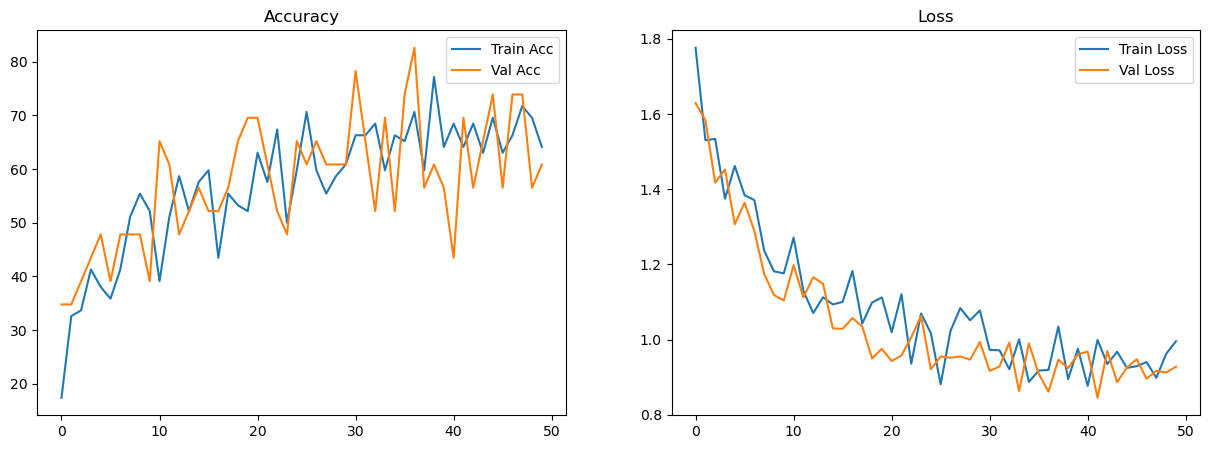

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].plot(train_accuracies, label='Train Acc')
ax[0].plot(val_accuracies, label='Val Acc')
ax[0].set_title('Accuracy')
ax[0].legend()

ax[1].plot(train_losses, label='Train Loss')
ax[1].plot(val_losses, label='Val Loss')
ax[1].set_title('Loss')
ax[1].legend()
plt.show()


📊 Classification Report:
              precision    recall  f1-score   support

        bent       0.40      0.40      0.40         5
       color       0.33      0.25      0.29         4
        flip       1.00      1.00      1.00         5
        good       0.50      0.75      0.60         4
     scratch       0.50      0.40      0.44         5

    accuracy                           0.57        23
   macro avg       0.55      0.56      0.55        23
weighted avg       0.56      0.57      0.56        23



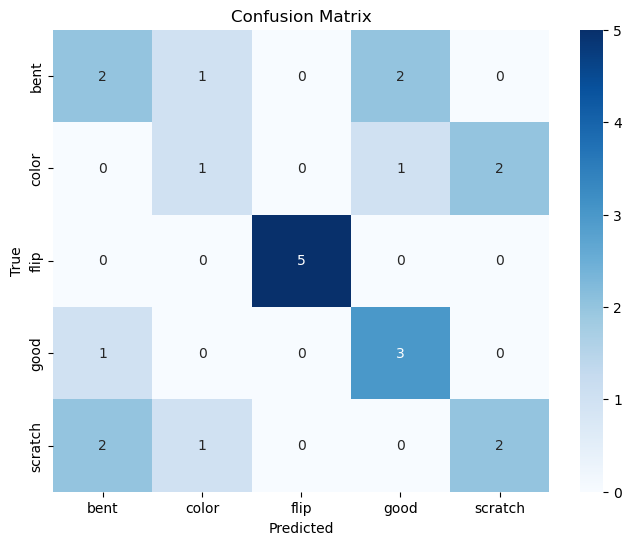

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 評估模型表現
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 中文類別名稱對照
labels_text = [idx_to_class[i] for i in range(len(idx_to_class))]

# 印出分類報告
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=labels_text))

# 混淆矩陣視覺化
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_text, yticklabels=labels_text)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [14]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        predicted = outputs.argmax(-1)
        print(predicted)
        print(labels)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f'Test accuracy is {100. * test_correct / test_total:.1f}%')

tensor([0, 2, 3, 2, 0, 2, 4, 3, 3, 4, 4, 2, 3, 3, 1, 3], device='cuda:0')
tensor([0, 2, 1, 2, 4, 2, 4, 3, 3, 4, 1, 2, 3, 0, 1, 3], device='cuda:0')
tensor([3, 2, 0, 3, 4, 0, 0], device='cuda:0')
tensor([1, 2, 0, 4, 4, 0, 0], device='cuda:0')
Test accuracy is 73.9%


In [15]:

# 修改 ResNet18 最後的 fc 為多層 MLP + Dropout 結構
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)
model.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)


c:\Users\tubew\anaconda3\envs\pytorch3127\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\tubew\anaconda3\envs\pytorch3127\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
